# EV CVAE Training and Evaluation

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import math
import os
from pathlib import Path

In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import torch
import torch.nn.functional as F
from pytorch_graph import generate_architecture_diagram
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset

/home/epalacios-garcia/Projects/EV-CVAE/.venv/lib64/python3.13/site-packages/pytorch_graph/core/parser.py:18: UserWarning: torchinfo not available. Enhanced model summaries will be disabled.
  warnings.warn("torchinfo not available. Enhanced model summaries will be disabled.")


In [4]:
import ev_cvae.metrics as metrics
import ev_cvae.transform as tr
from ev_cvae import CVAE

In [5]:
plt.style.use("./pub_pdf.mplstyle")
mm = 1 / 25.4

## Configuration

In [6]:
rnd_seed = 0
torch.manual_seed(rnd_seed)
np.random.seed(rnd_seed)

### Path for data and results

In [7]:
BASE_PATH = Path("../data/")

# Input file path
INPUT_FILE = BASE_PATH / "processed" / "Transactions_preprocessedV3.4.7_combined.parquet"

# Checkpoint and stats paths
CKPT_PATH   = BASE_PATH / "generated" / "cvae_ev_v348.pt"
STATS_FILE  = BASE_PATH / "scaled" / "scale_stats.json"

### Features names and shorthands for plotting

In [8]:
x_cols   = ["PluggedInTime", "ChargingDuration", "ConsumedkWh", "TimeGapHours", "WeekTime_sin", "WeekTime_cos"]
pos_cols = ["PluggedInTime", "ChargingDuration", "ConsumedkWh", "TimeGapHours"]  # features that need log1p

names_mapping = {
    "PluggedInTime": r'$\Delta t_\mathrm{ses\_h}$',
    "ChargingDuration": r'$\Delta t_\mathrm{cha\_h}$', 
    "ConsumedkWh": r'$E$',
    "TimeGapHours": r'$\Delta t_\mathrm{gap\_h}$', 
    "WeekTime_sin": r'$t_\mathrm{avi\_sin}$', 
    "WeekTime_cos": r'$t_\mathrm{avi\_cos}$', 
}

### Model global configuration

In [9]:
# Model hyperparameters
feature_size = 6
class_size   = 8    # 7 day-of-week one-hot + 1 managed flag
latent_size  = 64
hidden_size  = 256

# Training hyperparameters
EPOCHS      = 60
lr          = 0.0003
weight_decay = 0
grad_clip   = None
beta        = 0.5
T           = 1.0   # sampling temperature

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## Load & Inspect Data

In [10]:
df = pl.read_parquet(INPUT_FILE)
feature_names = df.columns
print(f"Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

Loaded: 111,179 rows, 8 columns


PluggedInTime,ChargingDuration,ConsumedkWh,Part_of_Managed_Group,TimeGapHours,DayOfWeek,WeekTime_sin,WeekTime_cos
f64,f64,f64,i8,f64,f64,f64,f64
10.016667,4.683333,31.23,0,0.016667,2.0,0.529919,-0.848048
14.4,3.883333,26.24,0,0.033333,0.0,0.631739,0.775181
23.666667,3.116667,20.92,0,0.016667,4.0,-0.85588,-0.517174
83.766667,4.4,30.59,0,0.016667,3.0,-0.385561,-0.922682
12.2,3.666667,24.88,0,0.016667,3.0,-0.350207,-0.936672


## Data Preprocessing

In [11]:
# Build feature matrix X and condition matrix Y from the raw dataframe
X = df.select(x_cols).to_numpy().astype(np.float32)

day     = df["DayOfWeek"].to_numpy().astype(int)
managed = (df["Part_of_Managed_Group"].to_numpy().astype(np.int32) > 0).astype(np.float32).reshape(-1, 1)

# Condition vector: 7-dim day-of-week one-hot + 1 managed flag
C_day = np.eye(7)[day].astype(np.float32)
C     = np.concatenate([C_day, managed], axis=1).astype(np.float32)

# Apply log1p to non-negative features to reduce skew
pos_idx = [x_cols.index(c) for c in pos_cols]
X[:, pos_idx] = np.log1p(np.clip(X[:, pos_idx], 0, None))
# X = tr.log1p_cols(X, x_cols, pos_cols)

# Train / val / test split (70 / 15 / 15)
N   = len(X)
rng = np.random.default_rng(rnd_seed)
perm = rng.permutation(N)
n_tr = int(0.7 * N)
n_v  = int(0.15 * N)
train_idx = perm[:n_tr]
val_idx   = perm[n_tr:n_tr + n_v]
test_idx  = perm[n_tr + n_v:]

# Z-score scaling fitted on training data only
mu = X[train_idx].mean(axis=0)
sd = X[train_idx].std(axis=0, ddof=0)
sd[sd == 0] = 1.0
X_scaled = (X - mu) / sd
# X_scaled = tr.scale(X, mu, sd)

# Save scaling stats for later inverse-transform
stats = {
    "columns": x_cols,
    "stats": {
        c: {"mean": float(mu[j]), "std": float(sd[j]), "log1p": c in pos_cols}
        for j, c in enumerate(x_cols)
    }
}
with open(STATS_FILE, "w") as f:
    json.dump(stats, f, indent=2)

print(f"Train: {len(train_idx):,} | Val: {len(val_idx):,} | Test: {len(test_idx):,}")
print("Scaling stats saved to:", STATS_FILE)

Train: 77,825 | Val: 16,676 | Test: 16,678
Scaling stats saved to: ../data/scaled/scale_stats.json


### Build pytorch datasets and dataloaders

In [12]:
class XYDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X)
        self.Y = torch.from_numpy(Y)
    def __len__(self):  return len(self.X)
    def __getitem__(self, i): return self.X[i], self.Y[i]

train_ds = XYDataset(X_scaled[train_idx], C[train_idx])
val_ds   = XYDataset(X_scaled[val_idx],   C[val_idx])
test_ds  = XYDataset(X_scaled[test_idx],  C[test_idx])

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=256)
test_loader  = DataLoader(test_ds,  batch_size=256)

### Feature distribution histograms (log1p-transformed, before z-score scaling)

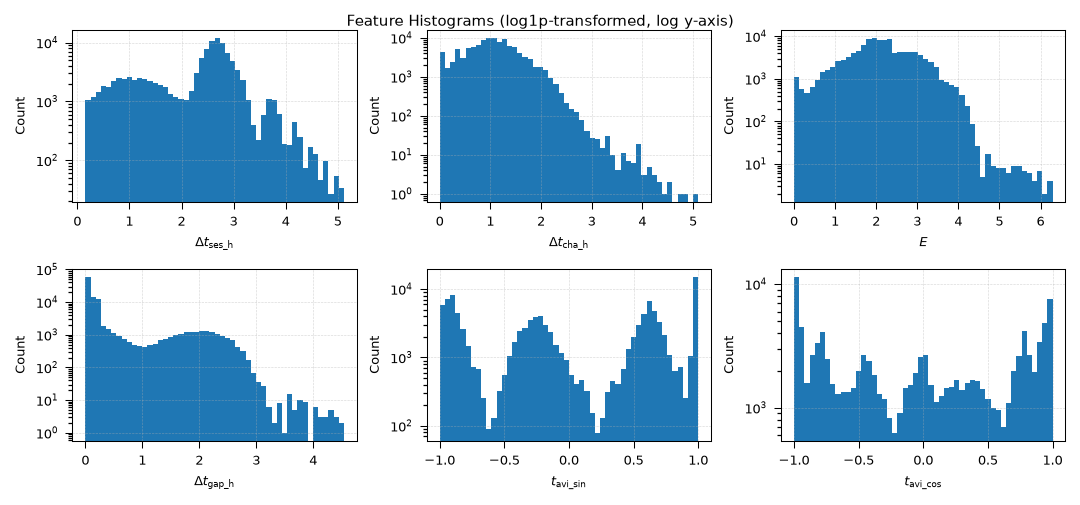

In [13]:
df_all = pd.DataFrame(X, columns=x_cols)

n_cols_plot = 3
n_rows_plot = int(np.ceil(len(x_cols) / n_cols_plot))
fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(180 * mm, 80 * mm), layout="constrained")
axes = axes.ravel()

for i, col in enumerate(x_cols):
    axes[i].hist(df_all[col], bins=50, density=False)
    axes[i].set_xlabel(names_mapping[col])
    axes[i].set_ylabel("Count")
    axes[i].set_yscale("log")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Feature Histograms (log1p-transformed, log y-axis)", y=1.02)
plt.show()

## Instantiate Model & Optimiser

In [14]:
model = CVAE(
    feature_size=feature_size,
    latent_size=latent_size,
    class_size=class_size,
    hidden_size=hidden_size,
    logvar_min=-6.0,
    logvar_max=1.5,
).to(device)

opt = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

# Per-feature loss weights (same order as x_cols)
# [PluggedInTime, ChargingDuration, ConsumedkWh, TimeGapHours, WeekTime_sin, WeekTime_cos]
raw_weights     = torch.tensor([2, 2.5, 1, 2.5, 0.5, 3.5], device=device, dtype=torch.float32)
feature_weights = raw_weights / raw_weights.mean()   # normalise so mean weight == 1

In [15]:
generate_architecture_diagram(
    model=model,
    input_shape=(1, 784),
    output_path= BASE_PATH / "figures" / "model_architecture.png",
    title="CVAE"
)

/home/epalacios-garcia/Projects/EV-CVAE/.venv/lib64/python3.13/site-packages/pytorch_graph/core/parser.py:100: UserWarning: Forward pass failed: CVAE.forward() missing 1 required positional argument: 'c'. Using structure-only parsing.
  warnings.warn(f"Forward pass failed: {e}. Using structure-only parsing.")


PosixPath('../data/figures/model_architecture.png')

## Training

In [16]:
train_losses_history = []
val_losses_history = []

train_feature_nll_history = []
val_feature_nll_history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0

    # accumulators for per-feature NLL
    train_feature_sums   = torch.zeros(feature_size, device=device)
    train_sample_count   = 0

    for xb, cb in train_loader:
        xb, cb = xb.to(device), cb.to(device)
        opt.zero_grad()

        # use cvae_loss once (no extra forward), with feature weights
        loss, _ = model.cvae_loss(xb, cb, beta=beta, reduce="sum", feature_weights=feature_weights)
        loss.backward()

        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        opt.step()

        train_loss += loss.item()

        # per-feature NLL for this batch
        with torch.no_grad():
            x_mu, x_logvar, _, _ = model(xb, cb)
            # [B, F] per-sample, per-feature NLL
            nll_bf = model.gaussian_nll(x_mu, x_logvar, xb, reduce="none")
            train_feature_sums += nll_bf.sum(dim=0)   # sum over batch, keep features
            train_sample_count += xb.size(0)

    avg_train_loss = train_loss / len(train_ds)
    train_losses_history.append(avg_train_loss)

    # average per-feature NLL over the whole training set
    avg_train_feature_nll = (train_feature_sums / train_sample_count).detach().cpu().numpy()
    train_feature_nll_history.append(avg_train_feature_nll)

    # Validation
    model.eval()
    val_loss = 0.0

    # accumulators for per-feature NLL on validation
    val_feature_sums   = torch.zeros(feature_size, device=device)
    val_sample_count   = 0

    with torch.no_grad():
        for xb, cb in val_loader:
            xb, cb = xb.to(device), cb.to(device)

            batch_loss, _ = model.cvae_loss(xb, cb, beta=beta, reduce="sum", feature_weights=feature_weights)
            val_loss += batch_loss.item()

            # NEW: per-feature NLL for this batch
            x_mu, x_logvar, _, _ = model(xb, cb)
            nll_bf = model.gaussian_nll(x_mu, x_logvar, xb, reduce="none")
            val_feature_sums += nll_bf.sum(dim=0)
            val_sample_count += xb.size(0)

    avg_val_loss = val_loss / len(val_ds)
    val_losses_history.append(avg_val_loss)

    # average per-feature NLL over the whole validation set
    avg_val_feature_nll = (val_feature_sums / val_sample_count).detach().cpu().numpy()
    val_feature_nll_history.append(avg_val_feature_nll)

    print(f"Epoch {epoch:03d} | train: {avg_train_loss:.4f} | val: {avg_val_loss:.4f}")
    print("  Train per-feature NLL:", avg_train_feature_nll)
    print("  Val   per-feature NLL:", avg_val_feature_nll)

avg_train_feature_nll.sum()

Epoch 001 | train: 5.8730 | val: 4.1011
  Train per-feature NLL: [1.2467091  1.0862612  1.1988784  0.4727528  1.3424798  0.44911626]
  Val   per-feature NLL: [ 1.1704477   0.8366654   1.0537372  -0.01467842  1.2625836  -0.09749174]
Epoch 002 | train: 3.5798 | val: 3.1527
  Train per-feature NLL: [ 1.1314665   0.80999017  1.0416536  -0.25366464  1.1011437  -0.23592031]
  Val   per-feature NLL: [ 1.0583403   0.72904706  1.0091074  -0.39466152  0.8325455  -0.33247375]
Epoch 003 | train: 2.6033 | val: 1.9101
  Train per-feature NLL: [ 0.92197114  0.46222544  0.9468544  -0.5422882   0.44849578 -0.3701773 ]
  Val   per-feature NLL: [ 0.82535434  0.05481074  0.87442344 -0.8296099   0.22107562 -0.42471033]
Epoch 004 | train: 1.1007 | val: 0.5675
  Train per-feature NLL: [ 0.7725679  -0.40657002  0.83559483 -1.1595392   0.12054064 -0.4541109 ]
  Val   per-feature NLL: [ 0.71236604 -0.6588825   0.7982274  -1.372088    0.00760044 -0.50392663]
Epoch 005 | train: 0.1448 | val: -0.1620
  Train per-f

np.float32(-8.351093)

### Global learning diagnostic

In [17]:
plt.style.use("./pub_pdf.mplstyle")

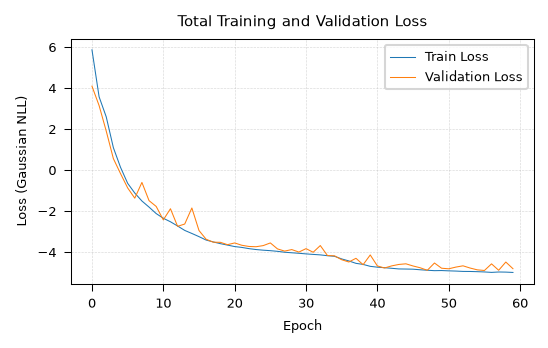

In [18]:
# Total loss curves
plt.figure(figsize=(90 * mm, 56 * mm), layout="constrained")
plt.plot(train_losses_history, label="Train Loss")
plt.plot(val_losses_history,   label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (Gaussian NLL)")
plt.title("Total Training and Validation Loss")
plt.legend()
plt.show()

### Feature-wise learning diagnostic

In [19]:
colors = plt.cm.tab20.colors

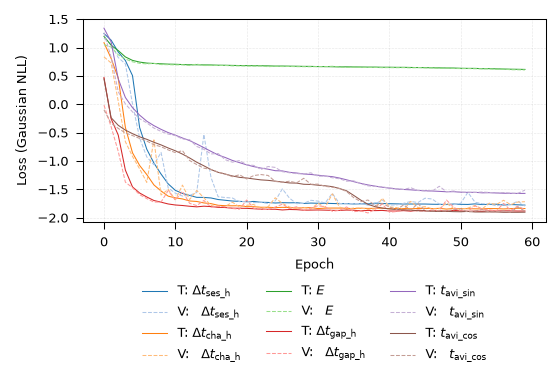

In [20]:
# Per-feature NLL loss curves
fig, ax = plt.subplots(figsize=(90 * mm, 60 * mm), layout="constrained")

train_lines, val_lines = [], []
j=0
for i, fname in enumerate(x_cols):
    train_curve = [e[i] for e in train_feature_nll_history]
    val_curve   = [e[i] for e in val_feature_nll_history]
    tl, = ax.plot(range(EPOCHS), train_curve, linestyle="-",  label=f"T: {names_mapping[fname]}", color=colors[j])
    j +=1
    vl, = ax.plot(range(EPOCHS), val_curve,   linestyle="--",label=f"V:   {names_mapping[fname]}", color=colors[j])
    j +=1
    train_lines.append(tl)
    val_lines.append(vl)

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (Gaussian NLL)")
ax.grid(True, alpha=0.3, ls="--")
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.25), frameon=False)
plt.show()

fig.savefig( BASE_PATH / "figures" / "loss.pdf",
    format="pdf",
    transparent=True,
    bbox_inches="tight")

## Save Model Checkpoint

In [21]:
torch.save({
    "model_state":  model.state_dict(),
    "feature_size": feature_size,
    "class_size":   class_size,
    "latent_size":  latent_size,
    "hidden_size":  hidden_size,
    "x_cols":       x_cols,
    "pos_cols":     pos_cols,
    "stats_file":   STATS_FILE,
}, CKPT_PATH)

print("Checkpoint saved:", CKPT_PATH)

Checkpoint saved: ../data/generated/cvae_ev_v348.pt


## Real vs Generated Comparison

### Generate conditional synthetic data

In [22]:
N_GEN        = 1000
day_idx      = 2    # 0=Mon … 6=Sun
managed_flag = 0    # 0=unmanaged, 1=managed

C_day = np.eye(7)[[day_idx] * N_GEN].astype(np.float32)
C_man = np.full((N_GEN, 1), managed_flag, dtype=np.float32)
C_gen = np.concatenate([C_day, C_man], axis=1)
X_gen_day_scaled = model.generate_samples(N_GEN, C_gen, device=device)

# Generate samples for a specific day and managed condition
print(f"Generated {N_GEN} samples for day_idx={day_idx}, managed={managed_flag}")
print(X_gen_day_scaled[:5])

Generated 1000 samples for day_idx=2, managed=0
[[-0.44516915 -0.2884939  -0.31471968 -0.4820602   0.70604944 -1.1049043 ]
 [-0.0171692   0.7887342   0.34711444 -0.40403268  0.63401437 -1.1684648 ]
 [-1.4642674  -0.94628066 -0.6925974  -0.46176812  1.0072199  -0.8469662 ]
 [ 0.6407286  -0.51367146 -0.7993909   3.5684824   0.88697445 -1.0188289 ]
 [-0.46461594  0.47832257 -0.02973402 -0.34960023  1.0225452  -0.8591552 ]]


In [23]:
# Load scaling stats and invert z-score + log1p transforms
X_gen_day = tr.inv_log1p_cols(tr.inv_scale(X_gen_day_scaled, mu, sd), x_cols, pos_cols)

# Compare generated samples against real scaled data for the same condition
mask = (day == day_idx) & (managed.squeeze() == managed_flag)
X_data_day_scaled = X_scaled[mask]
X_data_day = tr.inv_log1p_cols(tr.inv_scale(X_data_day_scaled, mu, sd), x_cols, pos_cols)

print(f"Real samples  (day={day_idx}, managed={managed_flag}): {X_data_day_scaled.shape[0]}")
print(f"Generated samples: {X_gen_day_scaled.shape[0]}")

Real samples  (day=2, managed=0): 3139
Generated samples: 1000


### Normalised histogram comparison

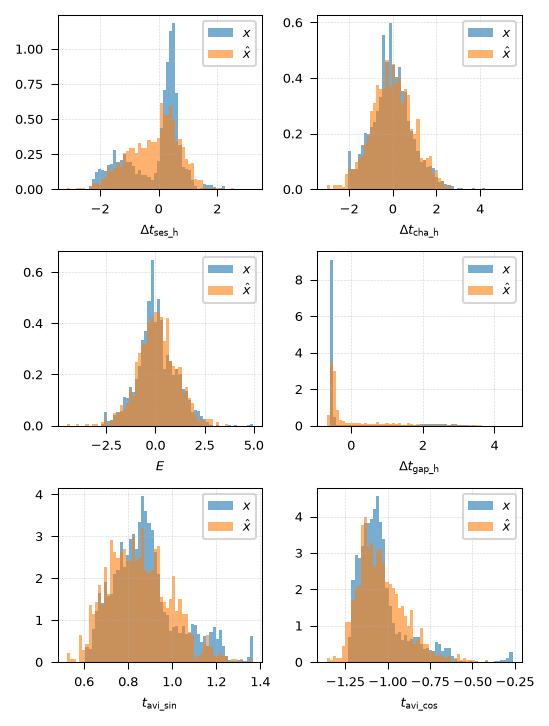

In [24]:
n_feats = len(x_cols)
n_cols = 2
n_rows = math.ceil(n_feats / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(90 * mm, 120 * mm), layout="constrained")
axes = axes.flatten()

for fi, fname in enumerate(x_cols):
    ax = axes[fi]
    real_vals, gen_vals = X_data_day_scaled[:, fi], X_gen_day_scaled[:, fi]
    vmin = min(real_vals.min(), gen_vals.min())
    vmax = max(real_vals.max(), gen_vals.max())
    ax.hist(real_vals, bins=60, range=(vmin, vmax), alpha=0.6, density=True, label="${x}$")
    ax.hist(gen_vals,  bins=60, range=(vmin, vmax), alpha=0.6, density=True, label="$\\hat{{x}}$")
    ax.set_xlabel(f"{names_mapping[fname]}")
    ax.legend()
    ax.grid(True)

for ax in axes[n_feats:]:
    ax.set_visible(False)
plt.show()

In [25]:
# Per-feature mean/std summary
print(f"Per-feature mean/std (scaled, day={day_idx}, managed={managed_flag}):")
for fi, fname in enumerate(x_cols):
    r, g = X_data_day_scaled[:, fi], X_gen_day_scaled[:, fi]
    print(f"{fname:20s} real μ={r.mean():7.3f}, σ={r.std(ddof=0):7.3f} | gen μ={g.mean():7.3f}, σ={g.std(ddof=0):7.3f}")

Per-feature mean/std (scaled, day=2, managed=0):
PluggedInTime        real μ= -0.102, σ=  0.921 | gen μ= -0.140, σ=  0.852
ChargingDuration     real μ= -0.028, σ=  0.927 | gen μ= -0.022, σ=  0.960
ConsumedkWh          real μ=  0.048, σ=  0.988 | gen μ=  0.091, σ=  1.008
TimeGapHours         real μ= -0.146, σ=  0.953 | gen μ= -0.094, σ=  0.797
WeekTime_sin         real μ=  0.879, σ=  0.149 | gen μ=  0.850, σ=  0.140
WeekTime_cos         real μ= -1.034, σ=  0.154 | gen μ= -1.037, σ=  0.139


### Real vs Generated Comparison (Unscaled, Test Split)

In [26]:
# 1. Select the X_scaled data corresponding to the test_idx
X_test_scaled = X_scaled[test_idx]

# 2. Select the day and managed data corresponding to the test_idx
day_test = day[test_idx]
managed_test = managed[test_idx].squeeze() # Remove extra dimension

# 3. Create a boolean mask by comparing day_test and managed_test with day_idx and managed_flag
mask_test = (day_test == day_idx) & (managed_test == managed_flag)

# 4. Apply the mask_test to X_test_scaled to get the real samples for the target day.
X_test_day_scaled = X_test_scaled[mask_test]

# Inverse-scaling X_test_day_scaled using log1p + z-score stats
X_test_day = tr.inv_log1p_cols(tr.inv_scale(X_test_day_scaled, mu, sd), x_cols, pos_cols)

print(f"Real samples for day {day_idx}, managed={managed_flag}: {X_test_day.shape[0]}")
print(f"Generated samples for day {day_idx}, managed={managed_flag}: {X_gen_day.shape[0]}")

Real samples for day 2, managed=0: 470
Generated samples for day 2, managed=0: 1000


### Unscaled histogram comparison for test split

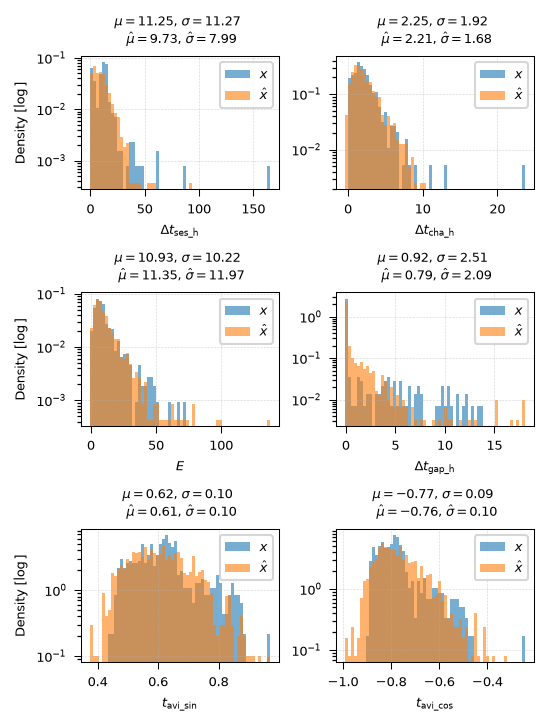

In [27]:
n_feats = len(x_cols)
n_cols = 2
n_rows = math.ceil(n_feats / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(90 * mm, 120 * mm), layout="constrained")
axes = axes.flatten()

log_y = True  # toggle this on/off

for fi, fname in enumerate(x_cols):
    ax = axes[fi]

    real_vals = X_test_day[:, fi]
    gen_vals  = X_gen_day[:, fi]

    r_mean, r_std = real_vals.mean(), real_vals.std(ddof=0)
    g_mean, g_std = gen_vals.mean(), gen_vals.std(ddof=0)

    r_min, r_max = real_vals.min(), real_vals.max()
    g_min, g_max = gen_vals.min(), gen_vals.max()

    # Common range so shapes are directly comparable
    vmin = min(real_vals.min(), gen_vals.min())
    vmax = max(real_vals.max(), gen_vals.max())

    ax.hist(
        real_vals,
        bins=60, # controls bar width (higher = thinner)
        range=(vmin, vmax),
        alpha=0.6,
        density=True,
        label="${x}$",
    )
    ax.hist(
        gen_vals,
        bins=60,
        range=(vmin, vmax),
        alpha=0.6,
        density=True,
        label="$\\hat{{x}}$",
    )
    ax.legend()

    if log_y:
        ax.set_yscale("log")  

    ax.set_xlabel(f"{names_mapping[fname]}")
    if fi%2 != 1:
        ax.set_ylabel(r'Density [$\log$]')
    ax.grid(True)
    ax.set_title(f"$\\mu = {r_mean:.2f}$, $\\sigma ={r_std:.2f}$ \n $\\hat\\mu = {g_mean:.2f}$, $\\hat\\sigma = {g_std:.2f}$", fontsize=6)

# Hide any unused axes
for ax in axes[n_feats:]:
    ax.set_visible(False)

fig.savefig("../data/figures/histogram_gen.pdf",
    format="pdf",
    transparent=True,
    bbox_inches="tight")   
plt.show()

In [28]:
print("Per-feature mean/std (unscaled, DayIndex =", {day_idx}, ", Managed=", {managed_flag}, ":")
for fi, fname in enumerate(x_cols):
    r = X_test_day[:, fi]
    g = X_gen_day[:, fi]

    r_mean, r_std = r.mean(), r.std(ddof=0)
    g_mean, g_std = g.mean(), g.std(ddof=0)

    r_min, r_max = r.min(), r.max()
    g_min, g_max = g.min(), g.max()

    print(
        f"{fname:20s} "
        f"real μ={r_mean:8.3f}, σ={r_std:8.3f}, min={r_min:8.3f}, max={r_max:8.3f} | "
        f"gen μ={g_mean:8.3f}, σ={g_std:8.3f}, min={g_min:8.3f}, max={g_max:8.3f}"
    )

Per-feature mean/std (unscaled, DayIndex = {2} , Managed= {0} :
PluggedInTime        real μ=  11.251, σ=  11.266, min=   0.167, max= 165.283 | gen μ=   9.726, σ=   7.986, min=  -0.433, max=  91.847
ChargingDuration     real μ=   2.248, σ=   1.921, min=   0.003, max=  23.700 | gen μ=   2.213, σ=   1.679, min=  -0.404, max=  10.043
ConsumedkWh          real μ=  10.935, σ=  10.222, min=   0.100, max=  71.900 | gen μ=  11.348, σ=  11.968, min=  -0.752, max= 137.419
TimeGapHours         real μ=   0.916, σ=   2.508, min=   0.000, max=  13.800 | gen μ=   0.786, σ=   2.089, min=  -0.085, max=  18.087
WeekTime_sin         real μ=   0.622, σ=   0.100, min=   0.438, max=   0.970 | gen μ=   0.608, σ=   0.100, min=   0.374, max=   0.966
WeekTime_cos         real μ=  -0.771, σ=   0.093, min=  -0.899, max=  -0.244 | gen μ=  -0.765, σ=   0.098, min=  -0.992, max=  -0.328


In [29]:
# Per-feature relative error summary
for fi, fname in enumerate(x_cols):
    r, g = X_test_day[:, fi], X_gen_day[:, fi]
    print(f"{fname:15s} mean_err={abs(g.mean()-r.mean())/abs(r.mean()+1e-8):6.3f}, std_err={abs(g.std()-r.std())/r.std():6.3f}")

PluggedInTime   mean_err= 0.136, std_err= 0.291
ChargingDuration mean_err= 0.016, std_err= 0.126
ConsumedkWh     mean_err= 0.038, std_err= 0.171
TimeGapHours    mean_err= 0.141, std_err= 0.167
WeekTime_sin    mean_err= 0.023, std_err= 0.001
WeekTime_cos    mean_err= 0.008, std_err= 0.046


### Save results to CSV file

In [30]:
import pandas as pd

rows = []
for fi, fname in enumerate(x_cols):
    r, g = X_test_day[:, fi], X_gen_day[:, fi]
    rows.append({
        "feature":   fname,
        "real_mean": r.mean(), "real_std": r.std(ddof=0), "real_min": r.min(), "real_max": r.max(),
        "gen_mean":  g.mean(), "gen_std":  g.std(ddof=0), "gen_min":  g.min(), "gen_max":  g.max(),
    })

stats_df = pd.DataFrame(rows).rename(columns={"feature": "Feature"}).set_index("Feature")
stats_df.columns = pd.MultiIndex.from_tuples([
    ("Real", "Mean"), ("Real", "Std dev"), ("Real", "Min"), ("Real", "Max"),
    ("Generated", "Mean"), ("Generated", "Std dev"), ("Generated", "Min"), ("Generated", "Max"),
])

display(stats_df)

out_path = BASE_PATH / "generated" / f"per_feature_stats_day_{day_idx}.csv"
stats_df.to_csv(out_path)
print("Saved stats to:", out_path)

Real                                   Generated  \
                       Mean    Std dev       Min         Max       Mean   
Feature                                                                   
PluggedInTime     11.251277  11.266303  0.166667  165.283340   9.726253   
ChargingDuration   2.248332   1.920875  0.003333   23.700003   2.212806   
ConsumedkWh       10.934597  10.221768  0.100000   71.900009  11.348371   
TimeGapHours       0.915780   2.508027  0.000000   13.800001   0.786461   
WeekTime_sin       0.622198   0.099560  0.438371    0.969842   0.608125   
WeekTime_cos      -0.770876   0.093315 -0.898794   -0.243736  -0.764765   

                                                   
                    Std dev       Min         Max  
Feature                                            
PluggedInTime      7.986494 -0.433270   91.847397  
ChargingDuration   1.679175 -0.403754   10.043009  
ConsumedkWh       11.967883 -0.752087  137.419083  
TimeGapHours       2.089028 -0.085008   18.086510  
WeekTime_sin       0.099698  0.374465    0.965991  
WeekTime_cos       0.097589 -0.991590   -0.328009

Saved stats to: ../data/generated/per_feature_stats_day_2.csv


## Evaluation Metrics (Wasserstein, Spearman, TSTR)

### Build a set of synthetic dataset with the same condition distribution as the test set

In [31]:
model.eval()
rng = np.random.default_rng(0)

X_test_scaled = X_scaled[test_idx]
X_test = tr.inv_log1p_cols(tr.inv_scale(X_test_scaled, mu, sd), x_cols, pos_cols)
C_test = C[test_idx]

N_sets = 10
X_test_gen_scaled_sets = []
X_test_gen_sets = []

for start in range(N_sets):
    x_sample = model.generate_samples(len(C_test), C_test, device=device)
    X_test_gen_scaled_sets.append(x_sample)
    X_test_gen_sets.append(tr.inv_log1p_cols(tr.inv_scale(x_sample, mu, sd), x_cols, pos_cols))

X_test_gen_scaled_sets = np.array(X_test_gen_scaled_sets)
X_test_gen_sets = np.array(X_test_gen_sets)

print("X_test_gen_scaled:", X_test_gen_sets.shape)
print("C_test:", C_test.shape)

X_test_gen_scaled: (10, 16678, 6)
C_test: (16678, 8)


#### Histogram synthetic test vs real test

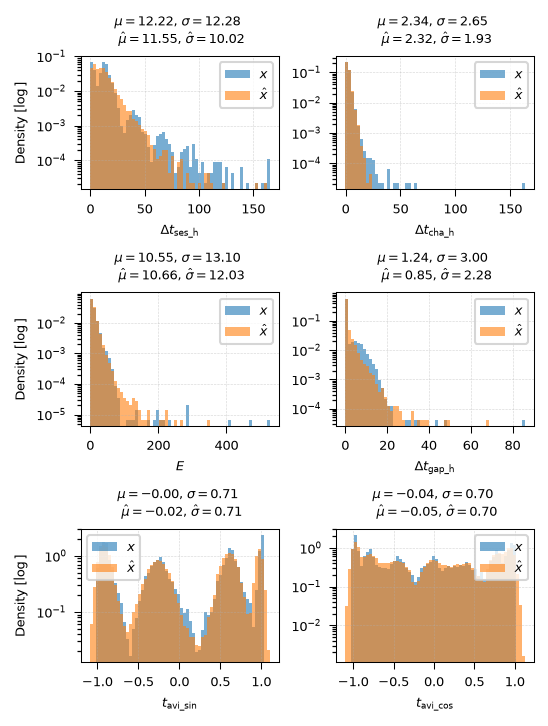

In [32]:
n_feats = len(x_cols)
n_cols = 2
n_rows = math.ceil(n_feats / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(90 * mm, 120 * mm), layout="constrained")
axes = axes.flatten()

log_y = True  # toggle this on/off

for fi, fname in enumerate(x_cols):
    ax = axes[fi]

    real_vals = X_test[:, fi]
    gen_vals  = X_test_gen_sets[0][:, fi]

    r_mean, r_std = real_vals.mean(), real_vals.std(ddof=0)
    g_mean, g_std = gen_vals.mean(), gen_vals.std(ddof=0)

    r_min, r_max = real_vals.min(), real_vals.max()
    g_min, g_max = gen_vals.min(), gen_vals.max()

    # Common range so shapes are directly comparable
    vmin = min(real_vals.min(), gen_vals.min())
    vmax = max(real_vals.max(), gen_vals.max())

    ax.hist(
        real_vals,
        bins=60, # controls bar width (higher = thinner)
        range=(vmin, vmax),
        alpha=0.6,
        density=True,
        label="${x}$",
    )
    ax.hist(
        gen_vals,
        bins=60,
        range=(vmin, vmax),
        alpha=0.6,
        density=True,
        label="$\\hat{{x}}$",
    )
    ax.legend()

    if log_y:
        ax.set_yscale("log")  

    ax.set_xlabel(f"{names_mapping[fname]}")
    if fi%2 != 1:
        ax.set_ylabel(r'Density [$\log$]')
    ax.grid(True)
    ax.set_title(f"$\\mu = {r_mean:.2f}$, $\\sigma ={r_std:.2f}$ \n $\\hat\\mu = {g_mean:.2f}$, $\\hat\\sigma = {g_std:.2f}$", fontsize=6)

# Hide any unused axes
for ax in axes[n_feats:]:
    ax.set_visible(False)

fig.savefig("../data/figures/histogram_gen_test.pdf",
    format="pdf",
    transparent=True,
    bbox_inches="tight")   
plt.show()

In [33]:
print("Per-feature mean/std (unscaled, DayIndex =", {day_idx}, ", Managed=", {managed_flag}, ":")
for fi, fname in enumerate(x_cols):
    r = X_test[:, fi]
    g  = X_test_gen_sets[0][:, fi]

    r_mean, r_std = r.mean(), r.std(ddof=0)
    g_mean, g_std = g.mean(), g.std(ddof=0)

    r_min, r_max = r.min(), r.max()
    g_min, g_max = g.min(), g.max()

    print(
        f"{fname:20s} "
        f"real μ={r_mean:8.3f}, σ={r_std:8.3f}, min={r_min:8.3f}, max={r_max:8.3f} | "
        f"gen μ={g_mean:8.3f}, σ={g_std:8.3f}, min={g_min:8.3f}, max={g_max:8.3f}"
    )

Per-feature mean/std (unscaled, DayIndex = {2} , Managed= {0} :
PluggedInTime        real μ=  12.218, σ=  12.283, min=   0.167, max= 165.283 | gen μ=  11.548, σ=  10.020, min=  -0.432, max= 161.624
ChargingDuration     real μ=   2.338, σ=   2.654, min=   0.000, max= 163.400 | gen μ=   2.321, σ=   1.926, min=  -0.553, max=  23.278
ConsumedkWh          real μ=  10.548, σ=  13.099, min=   0.000, max= 527.500 | gen μ=  10.664, σ=  12.033, min=  -0.899, max= 346.518
TimeGapHours         real μ=   1.238, σ=   2.997, min=   0.000, max=  85.967 | gen μ=   0.854, σ=   2.276, min=  -0.114, max=  68.553
WeekTime_sin         real μ=  -0.002, σ=   0.711, min=  -1.000, max=   1.000 | gen μ=  -0.018, σ=   0.709, min=  -1.090, max=   1.104
WeekTime_cos         real μ=  -0.043, σ=   0.702, min=  -1.000, max=   1.000 | gen μ=  -0.047, σ=   0.697, min=  -1.101, max=   1.126


### Build a set of synthetic dataset with the same condition distribution as the train set

In [34]:

model.eval()
rng = np.random.default_rng(0)

X_train_scaled = X_scaled[train_idx]
X_train = tr.inv_log1p_cols(tr.inv_scale(X_train_scaled, mu, sd), x_cols, pos_cols)
C_train = C[train_idx]

N_sets = 10
X_train_gen_scaled_sets = []
X_train_gen_sets = []

for start in range(N_sets):
    x_sample = model.generate_samples(len(C_train), C_train, device=device)
    X_train_gen_scaled_sets.append(x_sample)
    X_train_gen_sets.append(tr.inv_log1p_cols(tr.inv_scale(x_sample, mu, sd), x_cols, pos_cols))

X_train_gen_scaled_sets = np.array(X_train_gen_scaled_sets)
X_train_gen_sets = np.array(X_train_gen_sets)

print("X_train_gen_scaled:", X_train_gen_sets.shape)
print("C_train:", C_train.shape)

X_train_gen_scaled: (10, 77825, 6)
C_train: (77825, 8)


#### Histogram synthetic train vs real train

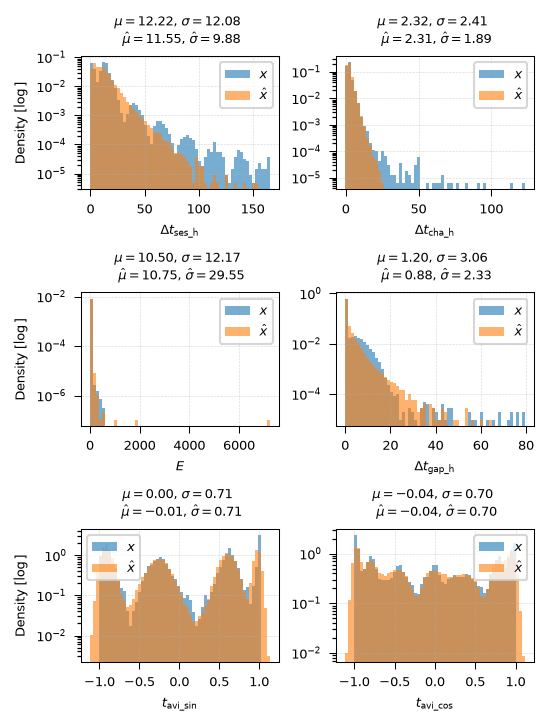

In [35]:
n_feats = len(x_cols)
n_cols = 2
n_rows = math.ceil(n_feats / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(90 * mm, 120 * mm), layout="constrained")
axes = axes.flatten()

log_y = True  # toggle this on/off

for fi, fname in enumerate(x_cols):
    ax = axes[fi]

    real_vals = X_train[:, fi]
    gen_vals  = X_train_gen_sets[0][:, fi]

    r_mean, r_std = real_vals.mean(), real_vals.std(ddof=0)
    g_mean, g_std = gen_vals.mean(), gen_vals.std(ddof=0)

    r_min, r_max = real_vals.min(), real_vals.max()
    g_min, g_max = gen_vals.min(), gen_vals.max()

    # Common range so shapes are directly comparable
    vmin = min(real_vals.min(), gen_vals.min())
    vmax = max(real_vals.max(), gen_vals.max())

    ax.hist(
        real_vals,
        bins=60, # controls bar width (higher = thinner)
        range=(vmin, vmax),
        alpha=0.6,
        density=True,
        label="${x}$",
    )
    ax.hist(
        gen_vals,
        bins=60,
        range=(vmin, vmax),
        alpha=0.6,
        density=True,
        label="$\\hat{{x}}$",
    )
    ax.legend()

    if log_y:
        ax.set_yscale("log")  

    ax.set_xlabel(f"{names_mapping[fname]}")
    if fi%2 != 1:
        ax.set_ylabel(r'Density [$\log$]')
    ax.grid(True)
    ax.set_title(f"$\\mu = {r_mean:.2f}$, $\\sigma ={r_std:.2f}$ \n $\\hat\\mu = {g_mean:.2f}$, $\\hat\\sigma = {g_std:.2f}$", fontsize=6)

# Hide any unused axes
for ax in axes[n_feats:]:
    ax.set_visible(False)

fig.savefig("../data/figures/histogram_gen_train.pdf",
    format="pdf",
    transparent=True,
    bbox_inches="tight")   
plt.show()

In [36]:
print("Per-feature mean/std (unscaled, DayIndex =", {day_idx}, ", Managed=", {managed_flag}, ":")
for fi, fname in enumerate(x_cols):
    r = X_train[:, fi]
    g  = X_train_gen_sets[0][:, fi]

    r_mean, r_std = r.mean(), r.std(ddof=0)
    g_mean, g_std = g.mean(), g.std(ddof=0)

    r_min, r_max = r.min(), r.max()
    g_min, g_max = g.min(), g.max()

    print(
        f"{fname:20s} "
        f"real μ={r_mean:8.3f}, σ={r_std:8.3f}, min={r_min:8.3f}, max={r_max:8.3f} | "
        f"gen μ={g_mean:8.3f}, σ={g_std:8.3f}, min={g_min:8.3f}, max={g_max:8.3f}"
    )

Per-feature mean/std (unscaled, DayIndex = {2} , Managed= {0} :
PluggedInTime        real μ=  12.216, σ=  12.077, min=   0.167, max= 165.867 | gen μ=  11.553, σ=   9.885, min=  -0.496, max= 153.122
ChargingDuration     real μ=   2.324, σ=   2.413, min=   0.000, max= 122.983 | gen μ=   2.311, σ=   1.891, min=  -0.597, max=  24.157
ConsumedkWh          real μ=  10.500, σ=  12.171, min=   0.000, max= 540.000 | gen μ=  10.750, σ=  29.550, min=  -0.987, max=7238.119
TimeGapHours         real μ=   1.202, σ=   3.056, min=   0.000, max=  79.450 | gen μ=   0.879, σ=   2.334, min=  -0.117, max=  64.076
WeekTime_sin         real μ=   0.003, σ=   0.712, min=  -1.000, max=   1.000 | gen μ=  -0.011, σ=   0.709, min=  -1.119, max=   1.133
WeekTime_cos         real μ=  -0.038, σ=   0.702, min=  -1.000, max=   1.000 | gen μ=  -0.041, σ=   0.699, min=  -1.116, max=   1.114


### Wasserstein and Spearman Correlation MAE

#### Synthetic test vs real test

In [37]:
w1_set = []
swd_set = []
cmae_set = []
for X_gen_scaled in X_test_gen_scaled_sets:
    w1 = metrics.w1_per_feature(X_test_scaled, X_gen_scaled) 
    swd = metrics.sliced_wasserstein(X_test_scaled, X_gen_scaled, n_proj=200, seed=rnd_seed)
    cmae = metrics.corr_mae(X_test_scaled, X_gen_scaled)
    w1_set.append(w1)
    swd_set.append(swd)
    cmae_set.append(cmae)
w1_set = np.array(w1_set)
swd_set = np.array(swd_set)
cmae_set = np.array(cmae_set)

In [38]:
df_test_w = pd.DataFrame(index=x_cols, data={"mean": w1_set.mean(axis=0), "std": w1_set.std(axis=0)})
df_test_w.loc["Sliced-W1"] = [swd_set.mean(), swd_set.std()]
df_test_w.loc["CMAE"] = [cmae_set.mean(), cmae_set.std()]
df_test_w

,mean,std
PluggedInTime,0.175026,0.002628
ChargingDuration,0.064290,0.002979
ConsumedkWh,0.051989,0.002521
TimeGapHours,0.158147,0.002225
WeekTime_sin,0.024039,0.000964
WeekTime_cos,0.015981,0.000925
Sliced-W1,0.057524,0.001171
CMAE,0.014543,0.001427


#### Syntethic train vs real train

In [39]:
w1_set = []
swd_set = []
cmae_set = []
for X_gen_scaled in X_train_gen_scaled_sets:
    w1 = metrics.w1_per_feature(X_train_scaled, X_gen_scaled) 
    swd = metrics.sliced_wasserstein(X_train_scaled, X_gen_scaled, n_proj=200, seed=rnd_seed)
    cmae = metrics.corr_mae(X_train_scaled, X_gen_scaled)
    w1_set.append(w1)
    swd_set.append(swd)
    cmae_set.append(cmae)
w1_set = np.array(w1_set)
swd_set = np.array(swd_set)
cmae_set = np.array(cmae_set)

In [40]:
df_train_w = pd.DataFrame(index=x_cols, data={"mean": w1_set.mean(axis=0), "std": w1_set.std(axis=0)})
df_train_w.loc["Sliced-W1"] = [swd_set.mean(), swd_set.std()]
df_train_w.loc["CMAE"] = [cmae_set.mean(), cmae_set.std()]
df_train_w

,mean,std
PluggedInTime,0.172452,0.000636
ChargingDuration,0.055067,0.001846
ConsumedkWh,0.045241,0.000877
TimeGapHours,0.152591,0.001565
WeekTime_sin,0.023086,0.000567
WeekTime_cos,0.015192,0.000329
Sliced-W1,0.048950,0.000720
CMAE,0.013815,0.000861


#### Real train vs real train

In [41]:
w1_set = []
swd_set = []
cmae_set = []
for _ in range(10):
    samples_idx = np.random.randint(0, X_train.shape[0], X_test.shape[0])
    w1 = metrics.w1_per_feature(X_train_scaled[samples_idx], X_test_scaled) # NEED TO FIX X_REAL_DAY ISSUES
    swd = metrics.sliced_wasserstein(X_train_scaled[samples_idx], X_test_scaled, n_proj=200, seed=rnd_seed)
    cmae = metrics.corr_mae(X_train_scaled[samples_idx], X_test_scaled)
    w1_set.append(w1)
    swd_set.append(swd)
    cmae_set.append(cmae)
w1_set = np.array(w1_set)
swd_set = np.array(swd_set)
cmae_set = np.array(cmae_set)

In [42]:
df_base_w = pd.DataFrame(index=x_cols, data={"mean": w1_set.mean(axis=0), "std": w1_set.std(axis=0)})
df_base_w.loc["Sliced-W1"] = [swd_set.mean(), swd_set.std()]
df_base_w.loc["CMAE"] = [cmae_set.mean(), cmae_set.std()]
df_base_w

,mean,std
PluggedInTime,0.011086,0.003583
ChargingDuration,0.019431,0.002775
ConsumedkWh,0.016073,0.004732
TimeGapHours,0.020259,0.006994
WeekTime_sin,0.011419,0.005268
WeekTime_cos,0.009581,0.004594
Sliced-W1,0.016897,0.001314
CMAE,0.006660,0.001378


In [43]:
df_merged = pd.DataFrame()
df_merged = df_merged.join(df_base_w, how="right")
df_merged = df_merged.join(df_train_w, how="right", rsuffix="_train")
df_merged = df_merged.join(df_test_w, how="right", rsuffix="_test")
df_merged = df_merged.iloc[:-2]
df_merged

,mean,std,mean_train,std_train,mean_test,std_test
PluggedInTime,0.011086,0.003583,0.172452,0.000636,0.175026,0.002628
ChargingDuration,0.019431,0.002775,0.055067,0.001846,0.064290,0.002979
ConsumedkWh,0.016073,0.004732,0.045241,0.000877,0.051989,0.002521
TimeGapHours,0.020259,0.006994,0.152591,0.001565,0.158147,0.002225
WeekTime_sin,0.011419,0.005268,0.023086,0.000567,0.024039,0.000964
WeekTime_cos,0.009581,0.004594,0.015192,0.000329,0.015981,0.000925


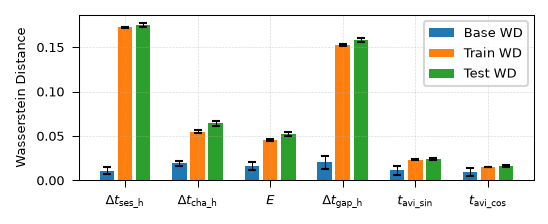

In [44]:
fig, ax = plt.subplots(figsize=(90 * mm, 35 * mm), layout="constrained")
x = np.arange(0,6)
ax.bar(x=x-0.25, height=df_merged["mean"], yerr=df_merged["std"], capsize=2, width=0.2, label="Base WD")
ax.bar(x=x, height=df_merged["mean_train"], yerr=df_merged["std_train"], capsize=2, width=0.2, label="Train WD")
ax.bar(x=x+0.25, height=df_merged["mean_test"], yerr=df_merged["std_test"], capsize=2, width=0.2, label="Test WD")
ax.set_ylabel("Wasserstein Distance")
ax.set_xticks(x)
names = [names_mapping[name] for name in  df_merged.index.values]
ax.set_xticklabels(names)
ax.legend()
fig.savefig("../data/figures/wasserstein_feat.pdf",
    format="pdf",
    transparent=True,
    bbox_inches="tight")   
plt.show()

### ACF MAE

In [45]:
acf_err = metrics.acf_mae(
    X_real=X_test, 
    X_synth=X_test_gen_sets[0], 
    C_real=C_test,
    C_synth=C_test,
    x_cols=x_cols, 
    feature="ConsumedkWh", 
    max_lag=24,
)
print("--- Temporal-ish structure ---")
print("ACF MAE (ConsumedkWh, lag<=24):", acf_err)

--- Temporal-ish structure ---
ACF MAE (ConsumedkWh, lag<=24): 0.01812328763019465


In [46]:
acf_err = metrics.acf_mae(
    X_real=X_train, 
    X_synth=X_train_gen_sets[0], 
    C_real=C_train,
    C_synth=C_train,
    x_cols=x_cols, 
    feature="ConsumedkWh", 
    max_lag=24,
)
print("--- Temporal-ish structure ---")
print("ACF MAE (ConsumedkWh, lag<=24):", acf_err)

--- Temporal-ish structure ---
ACF MAE (ConsumedkWh, lag<=24): 0.021778002609603435


## TSTR utility

### Train on synthetic and real datasets

In [47]:
# Run TSTR for ConsumedkWh, PluggedInTime, TimeGapHours, ChargingDuration
tstr_results = {}
m_real_e = None
m_synth_e = None
for target_feature in ["ConsumedkWh", "PluggedInTime", "TimeGapHours", "ChargingDuration"]:
    result, m_real, m_syn = metrics.tstr_regression(
        X_real_train=X_train_scaled,
        C_real_train=C_train,
        X_real_test=X_test_scaled,
        C_real_test=C_test,
        X_synth=X_train_gen_scaled_sets[0],
        C_synth=C_train,
        x_cols=x_cols,
        feature=target_feature,
        seed=rnd_seed
    )
    tstr_results[target_feature] = result
    if target_feature == "ConsumedkWh":
        m_real_e = m_real
        m_synth_e = m_syn

In [48]:
df_tstr = pd.DataFrame(tstr_results)
df_tstr.T

,MAE_TSTR_scaled,MAE_TRTR_scaled,ratio
ConsumedkWh,0.425653,0.388185,1.096521
PluggedInTime,0.613054,0.507030,1.209108
TimeGapHours,0.664968,0.597826,1.112310
ChargingDuration,0.392408,0.366070,1.071947


### Test both models for Energy Consumption across conditional features

Note: models are not retrained.

In [49]:
# Synthetic
day_test = np.argmax(C_test[:, :7], axis=1).astype(int)
man_test = C_test[:, 7].round().astype(int)

results = []

for d in range(7):
    for m in [0, 1]:

        mask_test = (day_test == d) & (man_test == m)

        if mask_test.sum() < 200:
            # skip tiny groups to avoid unstable regression
            continue

        out = metrics.tstr_prediction(
            m_real = m_real_e,
            m_syn = m_synth_e,
            X_real_test = X_test_scaled[mask_test],
            C_real_test = C_test[mask_test],
            x_cols=x_cols,
            feature="ConsumedkWh",
        )

        results.append({
            "day": d,
            "managed": m,
            "MAE_TRTR": out["MAE_TRTR_scaled"],
            "MAE_TSTR": out["MAE_TSTR_scaled"],
            "ratio": out["ratio"]
        })

In [50]:
df_tstr = pd.DataFrame(results)
df_tstr = df_tstr.sort_values(["managed", "day"])

day_map = {0:"Mon",1:"Tue",2:"Wed",3:"Thu",4:"Fri",5:"Sat",6:"Sun"}
df_tstr["day_name"] = df_tstr["day"].map(day_map)

#### Per condition results

In [51]:
df_no_mag = df_tstr[df_tstr["managed"] == 0]
df_mag = df_tstr[df_tstr["managed"] == 1]

In [52]:
df_no_mag

,day,managed,MAE_TRTR,MAE_TSTR,ratio,day_name
0,0,0,0.374531,0.409987,1.094667,Mon
2,1,0,0.386542,0.403072,1.042764,Tue
4,2,0,0.385414,0.398058,1.032807,Wed
6,3,0,0.385652,0.407770,1.057351,Thu
8,4,0,0.377103,0.403737,1.070629,Fri
10,5,0,0.369354,0.389733,1.055177,Sat
12,6,0,0.385620,0.392265,1.017231,Sun


In [53]:
df_mag

,day,managed,MAE_TRTR,MAE_TSTR,ratio,day_name
1,0,1,0.383742,0.442401,1.152861,Mon
3,1,1,0.389367,0.422978,1.086324,Tue
5,2,1,0.383752,0.418784,1.091290,Wed
7,3,1,0.363794,0.422424,1.161164,Thu
9,4,1,0.390041,0.431882,1.107273,Fri
11,5,1,0.399995,0.435524,1.088822,Sat
13,6,1,0.422499,0.447309,1.058722,Sun


#### TSTR/TRTR ration plot

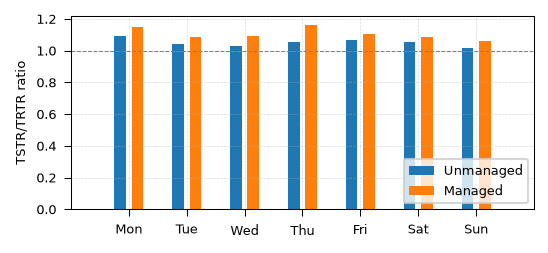

In [54]:
fig, ax = plt.subplots(figsize=(90 * mm, 40 * mm), layout="constrained")
x = np.arange(0,7)
ax.bar(x=x-0.15, height=df_no_mag["ratio"],  width=0.2, label="Unmanaged")
ax.bar(x=x+0.15, height=df_mag["ratio"],width=0.2, label="Managed")
ax.set_ylabel("TSTR/TRTR ratio")
ax.plot([-1, 7], [1, 1], ls="dashed", color="gray")

ax.set_xlim([-1, 7])
ax.set_xticks(x)
ax.set_xticklabels(df_no_mag["day_name"])
ax.legend(loc="lower right")
fig.savefig("../data/figures/tstr_trtr_ratio.pdf",
    format="pdf",
    transparent=True,
    bbox_inches="tight")   
plt.show()

## Full Synthetic Dataset Generation (All Days × Managed Flags)

In [55]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

N_PER_SCENARIO = 500
LATENT_DIM = latent_size  

model.eval()

all_rows = []
scenario_id = 0

for day_idx in range(7):              # 0..6
    for managed_flag in [0, 1]:        # 0=unmanaged, 1=managed

        # ---- Build condition exactly like training ----
        # DayOfWeek needs to be one-hot encoded (7 dimensions)
        day_one_hot = torch.nn.functional.one_hot(torch.tensor(day_idx, dtype=torch.long), num_classes=7).to(DEVICE)
        # Managed is a scalar
        managed_tensor = torch.tensor([managed_flag], dtype=torch.float32).to(DEVICE)

        # Concatenate to form the full 8-dimensional condition vector for a single instance
        cond_single_instance = torch.cat([day_one_hot.float(), managed_tensor], dim=-1)

        # Repeat for the batch
        cond_batch = cond_single_instance.unsqueeze(0).repeat(N_PER_SCENARIO, 1)

        # ---- Sample latent ----
        z = torch.randn(N_PER_SCENARIO, LATENT_DIM).to(DEVICE)

        # ---- Decode ----
        with torch.no_grad():
            x_gen_mu, x_gen_logvar = model.decode(z, cond_batch) # Decode returns x_mu, x_logvar
            std = torch.exp(0.5 * x_gen_logvar)
            eps = torch.randn_like(std)
            x_gen = x_gen_mu + T * std * eps

        # For synthetic data generation, often we use the mean or sample from predicted distribution
        # Here, I'll use the mean for simplicity, consistent with some generation examples above
        x_gen = x_gen.detach().cpu().numpy()

        x_unscaled = x_gen.copy()
        x_unscaled = tr.inv_log1p_cols(tr.inv_scale(x_unscaled, mu, sd), x_cols, pos_cols)

        # ---- Store rows ----
        for i in range(N_PER_SCENARIO):
            row = {
                "PluggedInTime": float(x_unscaled[i, 0]),
                "ChargingDuration": float(x_unscaled[i, 1]),
                "ConsumedkWh": float(x_unscaled[i, 2]),
                "TimeGapHours": float(x_unscaled[i, 3]),
                "WeekTime_sin": float(x_unscaled[i, 4]),
                "WeekTime_cos": float(x_unscaled[i, 5]),
                "DayOfWeek": day_idx,
                "Managed": managed_flag,
                "ScenarioID": scenario_id
            }
            all_rows.append(row)

        scenario_id += 1

df = pd.DataFrame(all_rows)

In [56]:
# Save synthetic dataset
out_drive = BASE_PATH / "test" / "synthetic_by_day_managed.parquet"
df.to_parquet(out_drive, index=False)

print("Done.")
print("Total rows:", len(df))

Done.
Total rows: 7000


## Format & save generated per day output

### Inverse Scaling

In [57]:
# Recover day-of-week and hour-of-day from cyclic encoding
week_angle  = np.arctan2(X_gen_day[:, 4], X_gen_day[:, 5])
week_angle  = np.where(week_angle < 0, week_angle + 2 * np.pi, week_angle)
sec_of_week = week_angle / (2 * np.pi) * 604_800
day_of_week = (sec_of_week // 86_400).astype(int)
hour_of_day = (sec_of_week % 86_400) / 3600

print("Sample day / hour:")
print(np.c_[day_of_week[:5], hour_of_day[:5]])

Sample day / hour:
[[ 2.         21.12329483]
 [ 2.         22.97336388]
 [ 2.         13.2614584 ]
 [ 2.         17.27270317]
 [ 2.         13.24036503]]


In [58]:
# Build a human-readable DataFrame with reconstructed times
def hours_to_hhmm(h):
    if pd.isna(h): return "NaN"
    h  = h % 24
    hh = int(h)
    mm = int(round((h - hh) * 60))
    return f"{hh:02d}:{mm:02d}"

weekday_names = np.array(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])

gen_df = pl.DataFrame(X_gen_day, schema=x_cols).select([pl.all().round(7)])

output_df = pd.DataFrame(X_gen_day, columns=x_cols).round(3)
output_df["DayIndex"]  = day_of_week.astype(int)
output_df["HourOfDay"] = hour_of_day
output_df["Day"]       = weekday_names[output_df["DayIndex"] % 7]

output_df["Plug-in_Time"] = np.vectorize(hours_to_hhmm)(output_df["HourOfDay"])
output_df["PlugOutHr"]   = (output_df["HourOfDay"] + output_df["PluggedInTime"]) % 24
output_df["PlugOut"]     = np.vectorize(hours_to_hhmm)(output_df["PlugOutHr"])

output_df["ChargingStartHr"] = (output_df["HourOfDay"] + output_df["TimeGapHours"]) % 24
output_df["ChargingStart"]   = np.vectorize(hours_to_hhmm)(output_df["ChargingStartHr"])

output_df["ChargingEndHr"] = (output_df["ChargingStartHr"] + output_df["ChargingDuration"]) % 24
output_df["ChargingEnd"]   = np.vectorize(hours_to_hhmm)(output_df["ChargingEndHr"])

output_df = output_df.drop(columns=["WeekTime_sin", "WeekTime_cos", "PlugOutHr", "ChargingStartHr", "ChargingEndHr"])
output_df = output_df[["DayIndex", "Day", "Plug-in_Time", "PluggedInTime", "PlugOut",
                        "ChargingStart", "ChargingDuration", "ChargingEnd",
                        "ConsumedkWh", "TimeGapHours"]]

OUTPUT         = BASE_PATH / "generated" / "V3.4.6_Output.csv"
OUTPUT_Parquet = BASE_PATH / "generated" / "V3.4.67_Output.parquet"

gen_df.write_parquet(BASE_PATH / "generated" / "V3.4.6_generated.parquet")
output_df.to_csv(OUTPUT, index=False)
output_df.to_parquet(OUTPUT_Parquet, index=False)

print("Outputs saved.")
output_df.head(10)

Outputs saved.


,DayIndex,Day,Plug-in_Time,PluggedInTime,PlugOut,ChargingStart,ChargingDuration,ChargingEnd,ConsumedkWh,TimeGapHours
0,2,Wednesday,21:07,5.274,02:24,21:11,1.472,22:39,5.576,0.057
1,2,Wednesday,22:58,8.204,07:11,23:05,3.325,02:25,10.040,0.117
2,2,Wednesday,13:16,1.519,14:47,13:20,0.757,14:05,3.892,0.072
3,2,Wednesday,17:16,15.590,08:52,11:22,1.199,12:34,3.500,18.087
4,2,Wednesday,13:14,5.165,18:24,13:24,2.681,16:05,7.220,0.162
5,2,Wednesday,17:54,0.632,18:32,17:55,0.064,17:59,0.708,0.020
6,2,Wednesday,15:53,15.067,06:57,15:53,1.103,16:59,3.234,0.004
7,2,Wednesday,18:29,3.020,21:30,18:33,1.052,19:37,3.654,0.074
8,2,Wednesday,15:40,6.551,22:13,15:42,1.945,17:39,14.446,0.037
9,2,Wednesday,17:00,4.155,21:09,17:01,0.260,17:16,0.961,0.008
